In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
words = open('names.txt', 'r').read().splitlines()

In [3]:
words[:10]

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn']

In [4]:
len(words)

32033

In [5]:
chars = sorted(list(set(''.join(words))))
stoi = {s : i + 1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i : s for s, i in stoi.items()}

vocab_size = len(itos)

In [6]:
# Building the dataset :
block_size = 3

def build_dataset(words) :
    X, Y = [], []
    for w in words :
        context = [0] * block_size
        for ch in w + '.' :
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [7]:
# MLP :
n_embd = 10
n_hidden = 200

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, n_embd), generator = g)

W1 = torch.randn((n_embd * block_size, n_hidden), generator = g) * (5 / 3) / ((n_embd * block_size) ** 0.5) # from Kaiming's paper
#b1 = torch.randn(n_hidden, generator = g) * 0.01

W2 = torch.randn((n_hidden, vocab_size), generator = g) * 0.01
b2 = torch.rand(vocab_size, generator = g) * 0

bngain = torch.ones((1, n_hidden))
bnbias = torch.zeros((1, n_hidden))
bnmean_running = torch.zeros((1, n_hidden))
bnstd_running = torch.ones((1, n_hidden))

parameters = [C, W1, W2, b2, bngain, bnbias]
print(sum(p.nelement() for p in parameters))
for p in parameters : p.requires_grad = True

12097


In [8]:
max_steps = 10000
batch_size = 32
lossi = []

for i in range(max_steps):
  
    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y
    
    # forward pass
    emb = C[Xb] 
    embcat = emb.view(emb.shape[0], -1) 
    # LInear layer :
    hpreact = embcat @ W1 #+ b1 
    # Batchnorm layer :
    bnmeani = hpreact.mean(0, keepdim = True)
    bnstdi = hpreact.std(0, keepdim = True)
    hpreact = bngain * (hpreact - bnmeani) / bnstdi + bnbias

    with torch.no_grad() :
        bnmean_running = 0.999 * bnmean_running + 0.001 * bnmeani
        bnstd_running = 0.999 * bnstd_running + 0.001 * bnstdi

    # Non-linearity
    h = torch.tanh(hpreact) # hidden layer
    logits = h @ W2 + b2 # output layer
    loss = F.cross_entropy(logits, Yb) # loss function
    
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    
    # update
    lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
    for p in parameters:
        p.data += -lr * p.grad
    
    # track stats
    if i % 10000 == 0: # print every once in a while
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())


      0/  10000: 3.2976


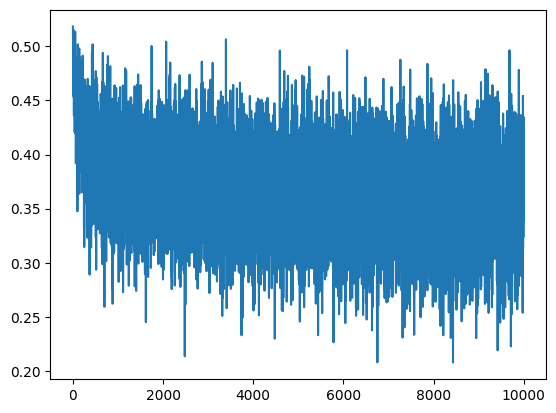

In [9]:
plt.plot(lossi)

In [10]:
# calibrate the batch norm at the end of training

with torch.no_grad():
  # pass the training set through
  emb = C[Xtr]
  embcat = emb.view(emb.shape[0], -1)
  hpreact = embcat @ W1 # + b1
  # measure the mean/std over the entire training set
  bnmean = hpreact.mean(0, keepdim=True)
  bnstd = hpreact.std(0, keepdim=True)

In [11]:
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
    x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
    }[split]
    emb = C[x] # (N, block_size, n_embd)
    embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
    hpreact = embcat @ W1 # + b1 
    hpreact = bngain * (hpreact - bnmean_running) / bnstd_running + bnbias
    h = torch.tanh(embcat @ W1) # + b1) # (N, n_hidden)
    logits = h @ W2 + b2 # (N, vocab_size)
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.729543447494507
val 2.7268519401550293


In [27]:
# deeper network : Pytorchifying:)

class Linear :
    def __init__(self, fan_in, fan_out, bias = True) :
        self.weight = torch.randn((fan_in, fan_out), generator = g) / fan_in ** 0.5 # kaiming factor included :)
        self.bias = torch.zeros(fan_out) if bias else None

    def __call__(self, x) :
        self.out = x @ self.weight
        if self.bias is not None : 
            self.out += self.bias
        return self.out

    def parameters(self) :
        return [self.weight] + ([self.bias] if self.bias is not None else [])

class BatchNorm1d :
    def __init__(self, dim, eps = 1e-5, momentum = 0.1) :
        # Declaration :
        self.eps = eps
        self.momentum = momentum
        self.training = True
        # Parameters :
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)
        # buffers :
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)

    def __call__(self, x) :
        # Forward pass :
        if self.training :
            xmean = x.mean(0, keepdim = True)
            xvar = x.var(0, keepdim = True)
        else :
            xmean = self.running_mean
            xvar = self.running_var

        xhat = (x - xmean) / torch.sqrt(xvar + self.eps) # Normalisation
        self.out = self.gamma * xhat + self.beta
        # Training :
        if self.training :
            with torch.no_grad() :
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
                self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
        return self.out

    def parameters(self) :
        return [self.gamma, self.beta]

class Tanh :
    def __call__(self, x) :
        self.out = torch.tanh(x)
        return self.out

    def parameters(self) : return []

n_embd = 10 # dimensionality of character embedding vectors
n_hidden = 100 # unmber of neurons in hidden layer of MLP
g = torch.Generator().manual_seed(2147483647) # for reproducibility

C = torch.randn((vocab_size, n_embd), generator = g)
Layers = [
    Linear(n_embd * block_size, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, vocab_size), BatchNorm1d(vocab_size),
]

with torch.no_grad() :
    Layers[-1].gamma *= 0.1
    #Layers[-1].weight *= 0.1 # Making last layer less confident
    for layer in Layers[:-1] :
        if isinstance(layer, Linear) :
            layer.weight *= 5 / 3 # Apply gain

parameters = [C] + [p for layer in Layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters))
for p in parameters : 
    p.requires_grad = True

47551


In [29]:
max_steps = 10000
batch_size = 32
lossi = []

for i in range(max_steps):
  
    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y
    
    # Forward pass : 
    emb = C[Xb]
    x = emb.view(emb.shape[0], -1)
    for layer in Layers :
        x = layer(x)
    loss = F.cross_entropy(x, Yb)

    # Backward pass : 
    for layer in Layers :
        layer.out.retain_grad()
    for p in parameters : 
        p.grad = None
    loss.backward()
    
    # update
    lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
    for p in parameters:
        p.data += -lr * p.grad
    
    # track stats
    if i % 10000 == 0: # print every once in a while
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())


      0/  10000: 3.0919


layer 2 (      Tanh): mean +0.00, std 0.63, saturated: 4.38%
layer 5 (      Tanh): mean -0.01, std 0.67, saturated: 4.38%
layer 8 (      Tanh): mean -0.00, std 0.67, saturated: 3.84%
layer 11 (      Tanh): mean +0.00, std 0.67, saturated: 3.69%
layer 14 (      Tanh): mean -0.00, std 0.67, saturated: 3.06%


Text(0.5, 1.0, 'Activation Distribution')

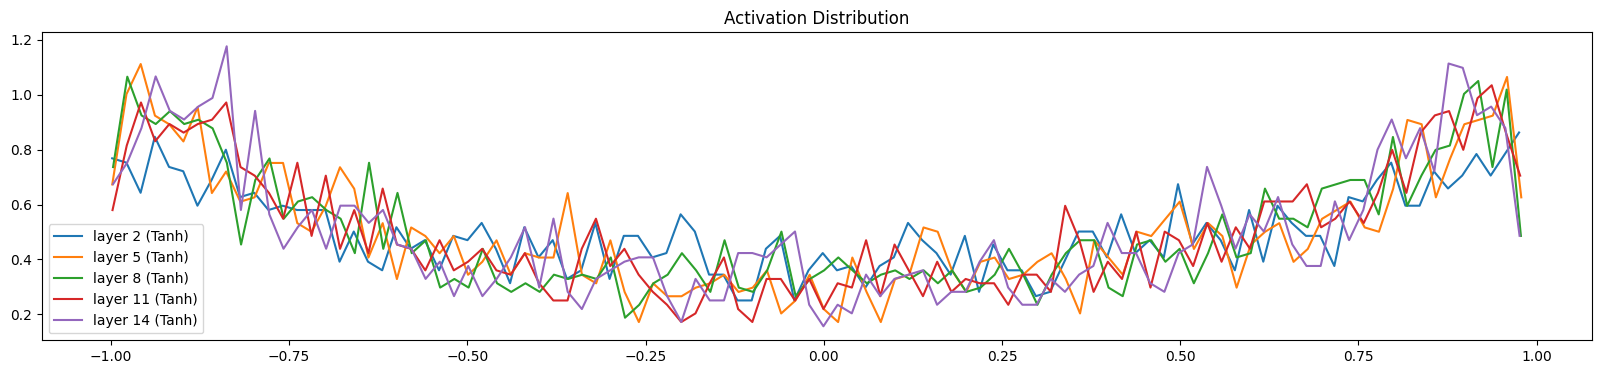

In [32]:
# Visualise :
plt.figure(figsize = (20, 4))
legends = []

for i, layer in enumerate(Layers[:-1]) :
    if isinstance(layer, Tanh) :
        t = layer.out
        print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' % (i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean()*100))
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'layer {i} ({layer.__class__.__name__})')
plt.legend(legends)
plt.title('Activation Distribution')

layer 2 (      Tanh): mean -0.00, std 0.00, saturated: 0.00%
layer 5 (      Tanh): mean +0.00, std 0.00, saturated: 0.00%
layer 8 (      Tanh): mean +0.00, std 0.00, saturated: 0.00%
layer 11 (      Tanh): mean -0.00, std 0.00, saturated: 0.00%
layer 14 (      Tanh): mean -0.00, std 0.00, saturated: 0.00%


Text(0.5, 1.0, 'Gradient Distribution')

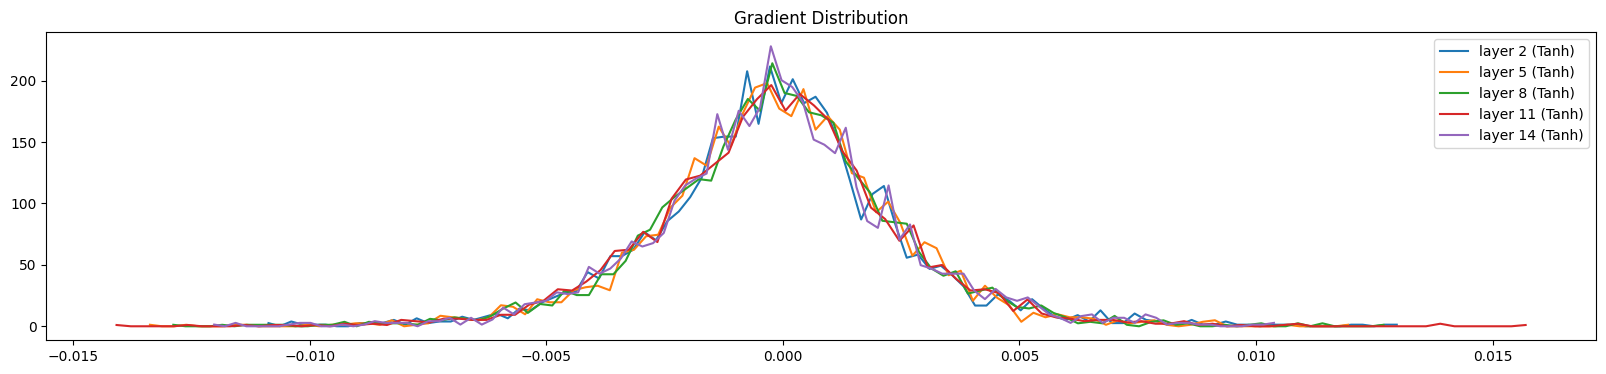

In [31]:
# Visualise :
plt.figure(figsize = (20, 4))
legends = []

for i, layer in enumerate(Layers[:-1]) :
    if isinstance(layer, Tanh) :
        t = layer.out.grad
        print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' % (i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean()*100))
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'layer {i} ({layer.__class__.__name__})')
plt.legend(legends)
plt.title('Gradient Distribution')